In [2]:
# ============================================================
# AI Innovators Lab: Movie Recommendation System
# Goal: Build a simple AI recommendation system.
#
# Input:
# - Favorite movie
#
# Output:
# - Recommended similar movies
#
# Dataset:
# MovieLens Latest Small Dataset
# Link: https://grouplens.org/datasets/movielens/latest/
#
# Camp version:
# We use movie title and genre similarity.
# This is easier for students to understand than advanced
# collaborative filtering.
# ============================================================

print("Welcome to the Movie Recommendation Project!")
print("Goal: Build an AI system that recommends movies based on your favorite movie.")



Welcome to the Movie Recommendation Project!
Goal: Build an AI system that recommends movies based on your favorite movie.


In [3]:
# ============================================================
# Step 1: Import required libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import requests
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries loaded successfully!")



Libraries loaded successfully!


In [4]:
# ============================================================
# Step 2: Download MovieLens Latest Small dataset
# ============================================================

dataset_url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
zip_file = "ml-latest-small.zip"
extract_folder = "movielens_dataset"

response = requests.get(dataset_url)

with open(zip_file, "wb") as file:
    file.write(response.content)

print("Dataset downloaded successfully!")

if not os.path.exists(extract_folder):
    os.makedirs(extract_folder)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted successfully!")



Dataset downloaded successfully!
Dataset extracted successfully!


In [5]:
# ============================================================
# Step 3: Load movie and rating data
#
# movies.csv contains:
# - movieId
# - title
# - genres
#
# ratings.csv contains:
# - userId
# - movieId
# - rating
# - timestamp
# ============================================================

movies_path = os.path.join(extract_folder, "ml-latest-small", "movies.csv")
ratings_path = os.path.join(extract_folder, "ml-latest-small", "ratings.csv")

movies = pd.read_csv(movies_path)
ratings = pd.read_csv(ratings_path)

print("Movies dataset loaded successfully!")
print("Ratings dataset loaded successfully!")

print("\nMovies:")
print(movies.head())

print("\nRatings:")
print(ratings.head())



Movies dataset loaded successfully!
Ratings dataset loaded successfully!

Movies:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Ratings:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [6]:
# ============================================================
# Step 4: Explore the dataset
# ============================================================

print("Number of movies:", len(movies))
print("Number of ratings:", len(ratings))
print("Number of users:", ratings["userId"].nunique())

# Average rating for each movie
movie_ratings = ratings.groupby("movieId")["rating"].agg(["mean", "count"]).reset_index()
movie_ratings.columns = ["movieId", "average_rating", "rating_count"]

movies = movies.merge(movie_ratings, on="movieId", how="left")

movies["average_rating"] = movies["average_rating"].fillna(0)
movies["rating_count"] = movies["rating_count"].fillna(0)

print("\nMovies with rating information:")
print(movies.head())



Number of movies: 9742
Number of ratings: 100836
Number of users: 610

Movies with rating information:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  average_rating  rating_count  
0  Adventure|Animation|Children|Comedy|Fantasy        3.920930         215.0  
1                   Adventure|Children|Fantasy        3.431818         110.0  
2                               Comedy|Romance        3.259615          52.0  
3                         Comedy|Drama|Romance        2.357143           7.0  
4                                       Comedy        3.071429          49.0  



Top 10 most rated movies:
                                          title  \
314                         Forrest Gump (1994)   
277            Shawshank Redemption, The (1994)   
257                         Pulp Fiction (1994)   
510            Silence of the Lambs, The (1991)   
1939                         Matrix, The (1999)   
224   Star Wars: Episode IV - A New Hope (1977)   
418                        Jurassic Park (1993)   
97                            Braveheart (1995)   
507           Terminator 2: Judgment Day (1991)   
461                     Schindler's List (1993)   

                                genres  average_rating  rating_count  
314           Comedy|Drama|Romance|War        4.164134         329.0  
277                        Crime|Drama        4.429022         317.0  
257        Comedy|Crime|Drama|Thriller        4.197068         307.0  
510              Crime|Horror|Thriller        4.161290         279.0  
1939            Action|Sci-Fi|Thriller        4.192446  

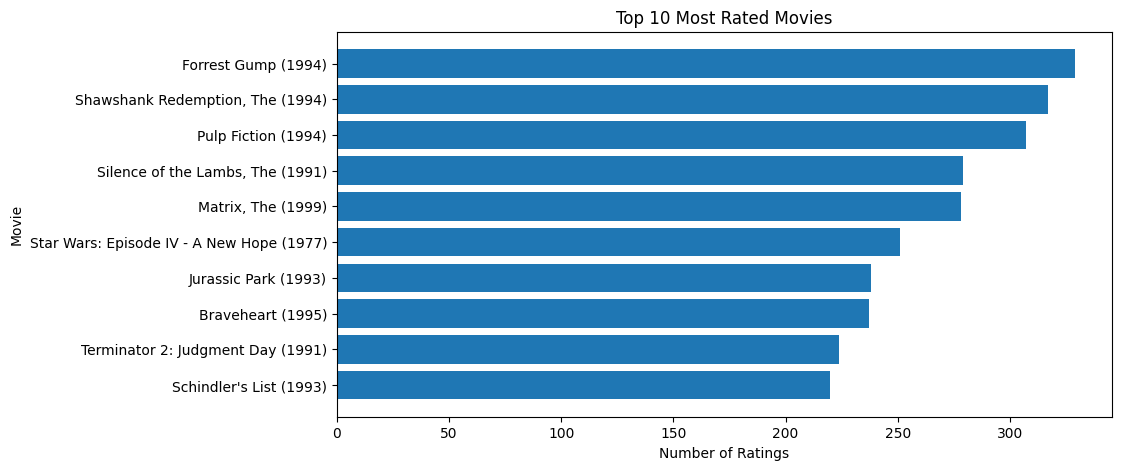

In [7]:
# ============================================================
# Step 5: Show popular movies
# ============================================================

popular_movies = movies.sort_values(
    by=["rating_count", "average_rating"],
    ascending=False
).head(10)

print("\nTop 10 most rated movies:")
print(popular_movies[["title", "genres", "average_rating", "rating_count"]])

plt.figure(figsize=(10, 5))
plt.barh(popular_movies["title"], popular_movies["rating_count"])
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")
plt.gca().invert_yaxis()
plt.show()



In [8]:
# ============================================================
# Step 6: Prepare movie text features
#
# We use title + genres to find similar movies.
#
# Example:
# Toy Story (1995), Adventure|Animation|Children|Comedy|Fantasy
#
# The model compares movie descriptions using text similarity.
# ============================================================

movies["genres_clean"] = movies["genres"].str.replace("|", " ", regex=False)

movies["movie_text"] = movies["title"] + " " + movies["genres_clean"]

print("\nMovie text examples:")
print(movies[["title", "genres", "movie_text"]].head())




Movie text examples:
                                title  \
0                    Toy Story (1995)   
1                      Jumanji (1995)   
2             Grumpier Old Men (1995)   
3            Waiting to Exhale (1995)   
4  Father of the Bride Part II (1995)   

                                        genres  \
0  Adventure|Animation|Children|Comedy|Fantasy   
1                   Adventure|Children|Fantasy   
2                               Comedy|Romance   
3                         Comedy|Drama|Romance   
4                                       Comedy   

                                          movie_text  
0  Toy Story (1995) Adventure Animation Children ...  
1          Jumanji (1995) Adventure Children Fantasy  
2             Grumpier Old Men (1995) Comedy Romance  
3      Waiting to Exhale (1995) Comedy Drama Romance  
4          Father of the Bride Part II (1995) Comedy  


In [9]:
# ============================================================
# Step 7: Convert movie text into numbers
#
# TF-IDF gives higher importance to meaningful words.
# Cosine similarity compares how similar two movies are.
# ============================================================

vectorizer = TfidfVectorizer(
    stop_words="english"
)

movie_vectors = vectorizer.fit_transform(movies["movie_text"])

similarity_matrix = cosine_similarity(movie_vectors, movie_vectors)

print("Movie similarity matrix created successfully!")
print("Matrix shape:", similarity_matrix.shape)



Movie similarity matrix created successfully!
Matrix shape: (9742, 9742)


In [10]:
# ============================================================
# Step 8: Create recommendation function
#
# Student types a favorite movie title.
# The function finds the closest movie title and recommends
# similar movies.
# ============================================================

def recommend_movies(favorite_movie, number_of_recommendations=5):
    favorite_movie = favorite_movie.lower()

    # Find movies that contain the typed title
    matching_movies = movies[movies["title"].str.lower().str.contains(favorite_movie, na=False)]

    if len(matching_movies) == 0:
        print("Sorry, I could not find that movie.")
        print("Try a shorter title, such as 'toy story', 'batman', or 'star wars'.")
        return

    # Use the first matching movie
    selected_movie_index = matching_movies.index[0]
    selected_movie_title = movies.loc[selected_movie_index, "title"]

    print("Selected movie:", selected_movie_title)

    # Get similarity scores for selected movie
    similarity_scores = list(enumerate(similarity_matrix[selected_movie_index]))

    # Sort movies by similarity score
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Skip the first movie because it is the same movie
    similar_movies = similarity_scores[1:number_of_recommendations + 1]

    print("\nRecommended Movies:")
    recommendations = []

    for rank, (movie_index, score) in enumerate(similar_movies, start=1):
        movie_title = movies.loc[movie_index, "title"]
        movie_genres = movies.loc[movie_index, "genres"]
        movie_rating = movies.loc[movie_index, "average_rating"]
        movie_rating_count = movies.loc[movie_index, "rating_count"]

        recommendations.append({
            "Rank": rank,
            "Movie": movie_title,
            "Genres": movie_genres,
            "Similarity Score": round(score, 3),
            "Average Rating": round(movie_rating, 2),
            "Number of Ratings": int(movie_rating_count)
        })

    recommendations_df = pd.DataFrame(recommendations)
    display(recommendations_df)

    return recommendations_df



In [11]:
# ============================================================
# Step 9: Try example recommendations
# ============================================================

recommend_movies("Toy Story", 5)

recommend_movies("Batman", 5)

recommend_movies("Star Wars", 5)



Selected movie: Toy Story (1995)

Recommended Movies:


,Rank,Movie,Genres,Similarity Score,Average Rating,Number of Ratings
0,1,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.880,3.86,97
1,2,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.821,4.11,55
2,3,"Toy, The (1982)",Comedy,0.538,2.38,4
3,4,We're Back! A Dinosaur's Story (1993),Adventure|Animation|Children|Fantasy,0.456,3.00,1
4,5,Now and Then (1995),Children|Drama,0.422,3.33,9


Selected movie: Batman Forever (1995)

Recommended Movies:


,Rank,Movie,Genres,Similarity Score,Average Rating,Number of Ratings
0,1,Batman (1966),Action|Adventure|Comedy,0.514,3.00,5
1,2,Batman (1989),Action|Crime|Thriller,0.513,3.43,189
2,3,Diamonds Are Forever (1971),Action|Adventure|Thriller,0.437,3.50,21
3,4,Batman: Year One (2011),Action|Animation|Crime,0.421,3.67,3
4,5,Batman Returns (1992),Action|Crime,0.416,3.02,60


Selected movie: Star Wars: Episode IV - A New Hope (1977)

Recommended Movies:


,Rank,Movie,Genres,Similarity Score,Average Rating,Number of Ratings
0,1,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Sci-Fi,0.523,3.11,140
1,2,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,0.509,4.22,211
2,3,Star Wars: Episode III - Revenge of the Sith (...,Action|Adventure|Sci-Fi,0.492,3.43,78
3,4,Comic-Con Episode IV: A Fan's Hope (2011),Documentary,0.482,2.00,1
4,5,Star Wars: Episode II - Attack of the Clones (...,Action|Adventure|Sci-Fi|IMAX,0.476,3.16,92


,Rank,Movie,Genres,Similarity Score,Average Rating,Number of Ratings
0,1,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Sci-Fi,0.523,3.11,140
1,2,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,0.509,4.22,211
2,3,Star Wars: Episode III - Revenge of the Sith (...,Action|Adventure|Sci-Fi,0.492,3.43,78
3,4,Comic-Con Episode IV: A Fan's Hope (2011),Documentary,0.482,2.00,1
4,5,Star Wars: Episode II - Attack of the Clones (...,Action|Adventure|Sci-Fi|IMAX,0.476,3.16,92


In [12]:
# ============================================================
# Step 10: Let students enter their favorite movie
# ============================================================

favorite_movie = input("Enter your favorite movie title: ")

recommendations = recommend_movies(favorite_movie, 5)



Enter your favorite movie title: John Wick
Selected movie: John Wick (2014)

Recommended Movies:


,Rank,Movie,Genres,Similarity Score,Average Rating,Number of Ratings
0,1,John Wick: Chapter Two (2017),Action|Crime|Thriller,0.731,4.14,7
1,2,John Q (2002),Crime|Drama|Thriller,0.489,2.91,11
2,3,John From (2015),Drama,0.475,1.00,1
3,4,John Adams (2008),Drama,0.343,4.00,2
4,5,"As Above, So Below (2014)",Horror|Thriller,0.339,3.00,1


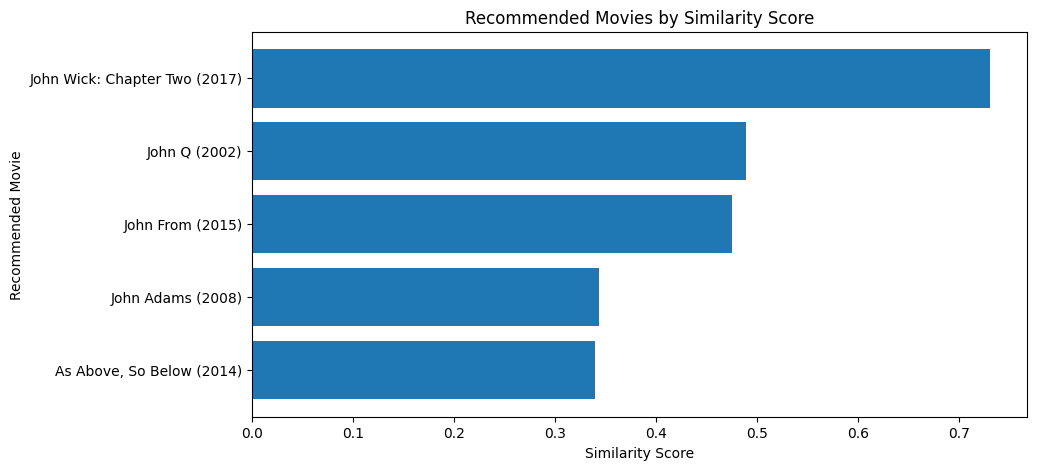

In [13]:
# ============================================================
# Step 11: Genre-based recommendation explanation
#
# This helps students understand why recommendations happen.
# ============================================================

if recommendations is not None:
    plt.figure(figsize=(10, 5))
    plt.barh(recommendations["Movie"], recommendations["Similarity Score"])
    plt.title("Recommended Movies by Similarity Score")
    plt.xlabel("Similarity Score")
    plt.ylabel("Recommended Movie")
    plt.gca().invert_yaxis()
    plt.show()



In [14]:
# ============================================================
# Step 12: Add a simple collaborative filtering idea
#
# This section recommends movies that are highly rated and popular
# in the same genre as the selected movie.
#
# This is still beginner-friendly.
# ============================================================

def recommend_popular_by_genre(genre_keyword, number_of_recommendations=5):
    genre_keyword = genre_keyword.lower()

    genre_movies = movies[
        movies["genres"].str.lower().str.contains(genre_keyword, na=False)
    ]

    if len(genre_movies) == 0:
        print("No movies found for that genre.")
        return

    # Recommend movies that have many ratings and high average ratings
    genre_movies = genre_movies[genre_movies["rating_count"] >= 50]

    recommended = genre_movies.sort_values(
        by=["average_rating", "rating_count"],
        ascending=False
    ).head(number_of_recommendations)

    print(f"Popular highly rated movies in genre: {genre_keyword}")
    display(recommended[["title", "genres", "average_rating", "rating_count"]])

    return recommended

# Example genre recommendations
recommend_popular_by_genre("Comedy", 5)
recommend_popular_by_genre("Action", 5)
recommend_popular_by_genre("Animation", 5)



Popular highly rated movies in genre: comedy


,title,genres,average_rating,rating_count
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,4.268041,97.0
899,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,4.232394,142.0
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.197068,307.0
3622,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,4.183333,120.0
314,Forrest Gump (1994),Comedy|Drama|Romance|War,4.164134,329.0


Popular highly rated movies in genre: action


,title,genres,average_rating,rating_count
2226,Fight Club (1999),Action|Crime|Drama|Thriller,4.272936,218.0
6710,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,4.238255,149.0
899,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,4.232394,142.0
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,4.231076,251.0
909,Apocalypse Now (1979),Action|Drama|War,4.219626,107.0


Popular highly rated movies in genre: animation


,title,genres,average_rating,rating_count
3984,Spirited Away (Sen to Chihiro no kamikakushi) ...,Adventure|Animation|Fantasy,4.155172,87.0
7355,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,4.109091,55.0
6772,WALL·E (2008),Adventure|Animation|Children|Romance|Sci-Fi,4.057692,104.0
868,Wallace & Gromit: The Wrong Trousers (1993),Animation|Children|Comedy|Crime,4.035714,56.0
7039,Up (2009),Adventure|Animation|Children|Drama,4.004762,105.0


,movieId,title,genres,average_rating,rating_count,genres_clean,movie_text
3984,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,Adventure|Animation|Fantasy,4.155172,87.0,Adventure Animation Fantasy,Spirited Away (Sen to Chihiro no kamikakushi) ...
7355,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,4.109091,55.0,Adventure Animation Children Comedy Fantasy IMAX,Toy Story 3 (2010) Adventure Animation Childre...
6772,60069,WALL·E (2008),Adventure|Animation|Children|Romance|Sci-Fi,4.057692,104.0,Adventure Animation Children Romance Sci-Fi,WALL·E (2008) Adventure Animation Children Rom...
868,1148,Wallace & Gromit: The Wrong Trousers (1993),Animation|Children|Comedy|Crime,4.035714,56.0,Animation Children Comedy Crime,Wallace & Gromit: The Wrong Trousers (1993) An...
7039,68954,Up (2009),Adventure|Animation|Children|Drama,4.004762,105.0,Adventure Animation Children Drama,Up (2009) Adventure Animation Children Drama


In [21]:
# ============================================================
# Step 13: Let students search by genre
# ============================================================

favorite_genre = input("Enter a movie genre, such as Comedy, Action, Animation, Drama, or Sci-Fi: ")

genre_recommendations = recommend_popular_by_genre(favorite_genre, 5)



Enter a movie genre, such as Comedy, Action, Animation, Drama, or Sci-Fi: Action
Popular highly rated movies in genre: action


,title,genres,average_rating,rating_count
2226,Fight Club (1999),Action|Crime|Drama|Thriller,4.272936,218.0
6710,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,4.238255,149.0
899,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,4.232394,142.0
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,4.231076,251.0
909,Apocalypse Now (1979),Action|Drama|War,4.219626,107.0


In [22]:
# ============================================================
# Step 14: Simple explanation for students
# ============================================================

explanation = """
How This Recommendation System Works:

1. Each movie has a title and genres.
2. We combine those into a text description.
3. The AI converts the text into numbers using TF-IDF.
4. The system compares movies using cosine similarity.
5. Movies with similar genres and words are recommended.

Example:
If you like Toy Story, the system may recommend other animated,
adventure, comedy, or family movies.
"""

print(explanation)




How This Recommendation System Works:

1. Each movie has a title and genres.
2. We combine those into a text description.
3. The AI converts the text into numbers using TF-IDF.
4. The system compares movies using cosine similarity.
5. Movies with similar genres and words are recommended.

Example:
If you like Toy Story, the system may recommend other animated,
adventure, comedy, or family movies.



In [23]:
# ============================================================
# Step 15: Save recommendation results
# ============================================================

if recommendations is not None:
    recommendations.to_csv("my_movie_recommendations.csv", index=False)
    print("Recommendations saved as my_movie_recommendations.csv")



Recommendations saved as my_movie_recommendations.csv


In [24]:
# ============================================================
# Step 16: Reflection questions for final showcase
# ============================================================

reflection_questions = [
    "1. What problem does your recommendation system solve?",
    "2. What dataset did you use?",
    "3. What information did the system use to compare movies?",
    "4. What movie did you enter as your favorite movie?",
    "5. What movies were recommended?",
    "6. Did the recommendations make sense? Why or why not?",
    "7. How could recommendation systems be used in real life?",
    "8. What are some risks of recommendation systems?",
    "9. How could this project be improved?"
]

print("\nReflection Questions:")
for question in reflection_questions:
    print(question)




Reflection Questions:
1. What problem does your recommendation system solve?
2. What dataset did you use?
3. What information did the system use to compare movies?
4. What movie did you enter as your favorite movie?
5. What movies were recommended?
6. Did the recommendations make sense? Why or why not?
7. How could recommendation systems be used in real life?
8. What are some risks of recommendation systems?
9. How could this project be improved?


# ============================================================
# Presentation Template for Students
# ============================================================

presentation_template = """
Project Title:
Movie Recommendation System

Team Members:
[Names]

Problem:
We wanted to build an AI system that recommends movies based on a user's favorite movie.

Dataset:
We used the MovieLens Latest Small dataset from GroupLens.
Dataset Link:
https://grouplens.org/datasets/movielens/latest/

Input:
Favorite movie title

Output:
Recommended similar movies

How It Works:
The system compares movie titles and genres using text similarity.
Movies with similar descriptions receive higher similarity scores.

Method Used:
TF-IDF Vectorization and Cosine Similarity

Demo:
We entered a favorite movie, and the system recommended similar movies.

What We Learned:
We learned how recommendation systems can suggest content based on similarity.

Real-World Use:
Recommendation systems are used by Netflix, YouTube, Spotify, Amazon, and other platforms.

Responsible AI Note:
Recommendation systems can influence what people watch, buy, or believe, so they should be designed carefully.

Future Improvement:
We could use user ratings, collaborative filtering, reviews, or viewing history to improve recommendations.
"""

print(presentation_template)